## 02 Proceso de EDA

En el siguiente notebook se describe el proceso que inicie para poder valorar las métricas estadisticas del negocio, tal como el convertion rate y su validación estadistica, sin embargo, aqui es donde podreos observar como al realizar el análisis de uso de su mapa geoespacial el producto recibe en un percentil 95.

En dicho punto el problema se convirtio en un proyecto donde el Machine Learning no supervisado podria aportar fuertemente para reducir el tráfico no deseado, ya que no solamente pueden reducir sus gastos de servicios sino que el ruido que generan estos agentes automáticos ensucia los datos correspondientes a la adquisición de usuarios.

La primer parte se podrá observar como el notebook evolucionaba hacia la aplicación de estadistica para optimizar métricas de negocio, mientras que la segunda parte empieza intensivamente a explorar los userAgents de la plataforma.

In [1]:
import pandas as pd
import geopandas as gpd
import sys
from pathlib import Path
import pprint
import folium
import os
import matplotlib.pyplot as plt
import numpy as np

ROOT_PROJECT = Path.cwd().parent
SRC = ROOT_PROJECT / 'src'

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


from utils.gather import (
    load_datasets,
)

from utils.statistics import (
    test_binomial_wilson,
    plot_wilson_interval,
    boostrap_function
)

In [2]:
conjunto_frames, metadata = load_datasets()
print(f'Metadata: ')
pprint.pprint(metadata, indent = 2)
geo_search, leads, search_console, tracking_preprocessed = conjunto_frames
complete_data_route = ROOT_PROJECT / 'Data' / 'csv'
busquedas_completas = pd.read_csv(
    os.path.join(complete_data_route, 'busquedas_escolares.csv'),
    dtype = {
        'user_pseudo_id' : 'string',
        'ga_client_id' : 'string',
    }
)

DATA_ROUTE = ROOT_PROJECT / 'Data'
CHECKPOINT_ROUTE = DATA_ROUTE / 'checkpoints'
BIG_QUERY = DATA_ROUTE / 'big_query'
big = pd.read_csv(
    os.path.join(BIG_QUERY, '20260101_20260519.csv'),
    dtype={
        'user_pseudo_id' : 'string'
    }
)

PREPROCESSED_ROUTE = DATA_ROUTE / 'processed'

Metadata: 
{ '/Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/EntregableTec/Data/processed/busquedas_unicas.csv': { 'nommbre_archivo': 'busquedas_unicas.csv'},
  '/Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/EntregableTec/Data/processed/leads_complete.csv': { 'nommbre_archivo': 'leads_complete.csv'},
  '/Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/EntregableTec/Data/processed/search_console.csv': { 'nommbre_archivo': 'search_console.csv'},
  '/Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/EntregableTec/Data/processed/tracking_preprocessed.csv': { 'nommbre_archivo': 'tracking_preprocessed.csv'}}


In [3]:
tracking_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10771 entries, 0 to 10770
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              10771 non-null  int64 
 1   time_inicio     10771 non-null  object
 2   time_creado     10771 non-null  object
 3   is_lead         10771 non-null  bool  
 4   url_ref         10771 non-null  object
 5   dispositivo     10771 non-null  object
 6   nivel           10771 non-null  object
 7   entidad         10771 non-null  object
 8   muicipio        10771 non-null  object
 9   nombre_escuela  10767 non-null  object
 10  cct             10771 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 852.1+ KB


## Parte 1- EDA sobre Analítica de Negocio

El siguiente EDA esta centrado en proporcional insights de Negocio respecto a Leads y adquisición de users. Valorar cuidar la privacidad de la data antes de exponerla a Git.

In [4]:
conteo_leads = len(leads)
conteo_users = len(tracking_preprocessed[tracking_preprocessed['is_lead'] == False])
proporcion_observada = conteo_leads / conteo_users
lead_ratio = conteo_leads/conteo_users * 100

In [5]:
tamano_muestra = conteo_leads + conteo_users

test_wilson = test_binomial_wilson(
    k = conteo_leads,
    n = tamano_muestra,
    p = proporcion_observada
)

[0.04430327708620633 - 0.050629206906643257 - 0.05239774295411772]


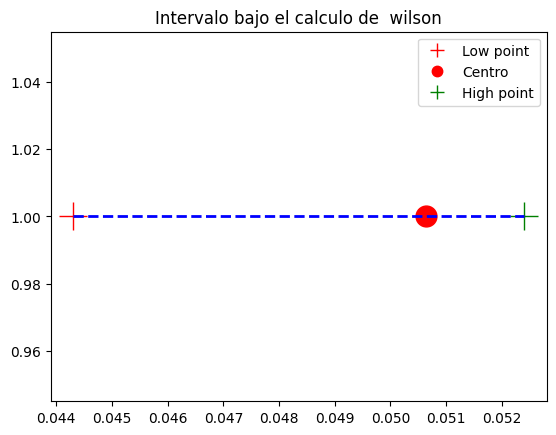

In [6]:
plot_wilson_interval(
    test_wilson,
    proporcion_observada,
)

In [7]:
res = test_wilson.proportion_ci(.95, method = 'wilson')
low, high = res

print(f'User base: {tamano_muestra}')
print(f'Conteo de Leads (True): {conteo_leads}')
print(f'Conteo de No Leads (False)): {conteo_users}')
print(f'Lead Ratio: {lead_ratio:.2f} %')
print(f'Nuestro intervalo de wilson es: {low} - {high}')

User base: 10770
Conteo de Leads (True): 519
Conteo de No Leads (False)): 10251
Lead Ratio: 5.06 %
Nuestro intervalo de wilson es: 0.04430327708620633 - 0.05239774295411772


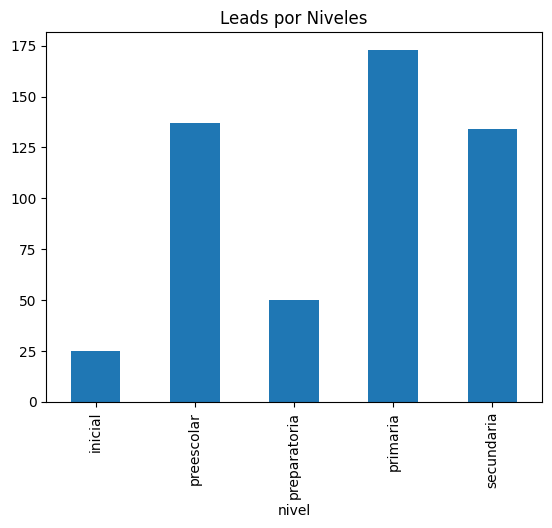

In [8]:
niveles_agrupados_leads = (
    leads
    .groupby('nivel')
    .size()
    .T
)

niveles_agrupados_leads.plot(kind = 'bar')
plt.title('Leads por Niveles')
plt.show()

## Estabilidad del convertion rate

A continuación se muestra la estabilidad del formulario, utilizando Bootstrap para conocer el rango de nuestro convertion rate.

In [9]:
tracking_preprocessed
data_list_track = tracking_preprocessed['is_lead'].astype(int)

bootstrap_resultado = boostrap_function(data_list_track)


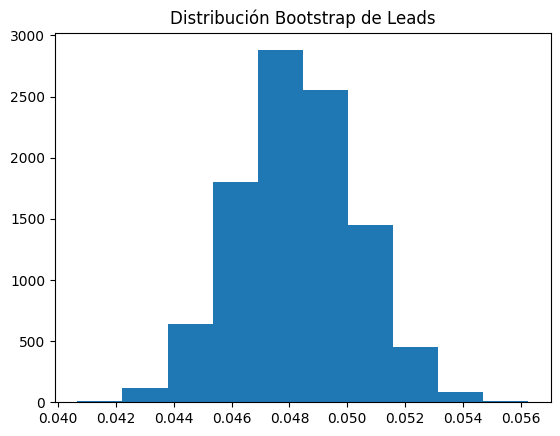

Low Bootstrap 0.044285581654442484
High Bootstrap 0.05236282610713954
STD Error:  0.0020476692825594106


In [10]:
plt.hist(bootstrap_resultado.bootstrap_distribution)
plt.title('Distribución Bootstrap de Leads')
plt.show()
print('Low Bootstrap', bootstrap_resultado.confidence_interval.low)
print('High Bootstrap', bootstrap_resultado.confidence_interval.high)
print('STD Error: ', bootstrap_resultado.standard_error)

## Revisión de outliers en busquedas por mapa

Durante el ETL pude notar que existen sesiones con mas de 1 busqueda. En el EDA quiero revisarlo mas a detalle, podría ser abuso por parte de bots/scrapeprs lo que dirigiria a gasto en tiempo de servidor.

In [11]:
busquedas_completas[busquedas_completas['ga_client_id'] == '698375144.1777477605']

,search_id,created_at,search_source,nivel,tipo,route_path,cct_context,center_lat,center_lon,radius_m,status,result_count,error_code,duration_ms,app_session_id,ga_client_id,ga_session_id,premium_schools,aparicion_premium,postal_code_used
3468,63038eab-80c1-4f7f-99ed-d3d6a41af46a,2026-05-11T14:52:10.367902+00:00,postal_code,primaria,publicas,/,NaN,21.101535,-101.583732,1500,success,7,NaN,1253,422dc9f7-e7b0-42fa-8a98-9d0464eb7c84,698375144.1777477605,1778511116,[],False,37295.0
3899,c68fc102-9a70-495a-a9ab-caef9be3fb08,2026-05-11T14:52:41.967748+00:00,postal_code,primaria,privadas,/,NaN,21.101535,-101.583732,1500,success,2,NaN,1254,422dc9f7-e7b0-42fa-8a98-9d0464eb7c84,698375144.1777477605,1778511116,[],False,37295.0
3900,60f1a7c1-1601-4ad0-9b3f-0faad5177af1,2026-05-11T14:52:52.630955+00:00,postal_code,primaria,publicas,/,NaN,21.101535,-101.583732,1500,success,7,NaN,568,422dc9f7-e7b0-42fa-8a98-9d0464eb7c84,698375144.1777477605,1778511116,[],False,37295.0
4243,ac16ed14-b37f-4cf1-b7fd-c29fb98e310a,2026-04-29T15:47:36.898707+00:00,near_me,primaria,privadas,/primaria/guanajuato/leon,NaN,21.060301,-101.571941,1500,success,1,NaN,807,935e2615-493b-4d9d-8532-3255dd4d5008,698375144.1777477605,1777477604,[],False,NaN
4244,1c7af9b8-b4ab-4f2b-b6db-fc6eb2a7fb98,2026-04-29T15:47:51.868988+00:00,near_me,primaria,publicas,/primaria/guanajuato/leon,NaN,21.060301,-101.571941,1500,success,0,NaN,731,a35439f5-9972-4b7b-a9cb-651c225ba3b0,698375144.1777477605,1777477604,[],False,NaN
4250,f978d5a0-63fa-4776-93f4-dd211dc57d8a,2026-04-29T16:00:03.026341+00:00,postal_code,primaria,privadas,/primaria/guanajuato/leon,NaN,21.129054,-101.747384,1500,success,4,NaN,1064,f4e39ab8-61ca-491c-ba88-4a2353bd3e7e,698375144.1777477605,1777477604,[],False,37355.0
4252,611639b3-9384-42d4-a72c-d0f3e6b12039,2026-04-29T16:00:28.079367+00:00,postal_code,primaria,publicas,/primaria/guanajuato/leon,NaN,21.129054,-101.747384,1500,success,5,NaN,777,f96dd261-5875-45b4-a12b-577796b0b829,698375144.1777477605,1777477604,[],False,37355.0
4255,7ca1e52c-4b77-4bd9-9481-fe8be4c33ec8,2026-04-29T16:02:06.216941+00:00,postal_code,primaria,publicas,/primaria/guanajuato/leon,NaN,21.153177,-101.736640,1500,success,8,NaN,1000,341ffcce-bc58-4c30-80b1-b8858cd61590,698375144.1777477605,1777477604,[],False,37358.0
4256,3c6346ec-8ad1-4bf4-a716-c2d219bb3ff5,2026-04-29T16:02:40.803463+00:00,postal_code,primaria,publicas,/primaria/guanajuato/leon,NaN,21.138377,-101.702911,1500,success,10,NaN,741,b561939a-8f1c-4c8e-b4bf-80d65f791930,698375144.1777477605,1777477604,[],False,37310.0
4265,c2e8f637-9bd6-45ab-8b64-db2941889bff,2026-04-29T16:59:24.077484+00:00,postal_code,primaria,publicas,/primaria/guanajuato/leon,NaN,21.101535,-101.583732,1500,success,7,NaN,1083,b561939a-8f1c-4c8e-b4bf-80d65f791930,698375144.1777477605,1777481722,[],False,37295.0


In [12]:
busquedas_completas['ga_client_id'] = busquedas_completas['ga_client_id'].astype(str)

In [13]:
frame = (
    busquedas_completas
    .groupby('ga_client_id')
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0 : 'numero_sesiones'})
)

In [14]:
frame['numero_sesiones'].describe()

count    2028.000000
mean        2.646943
std         8.003182
min         1.000000
25%         1.000000
50%         1.000000
75%         2.250000
max       320.000000
Name: numero_sesiones, dtype: float64

In [15]:
explorar_percentiles = np.arange(.90, 1, step = 0.0005)
quantiles = frame['numero_sesiones'].quantile(explorar_percentiles)

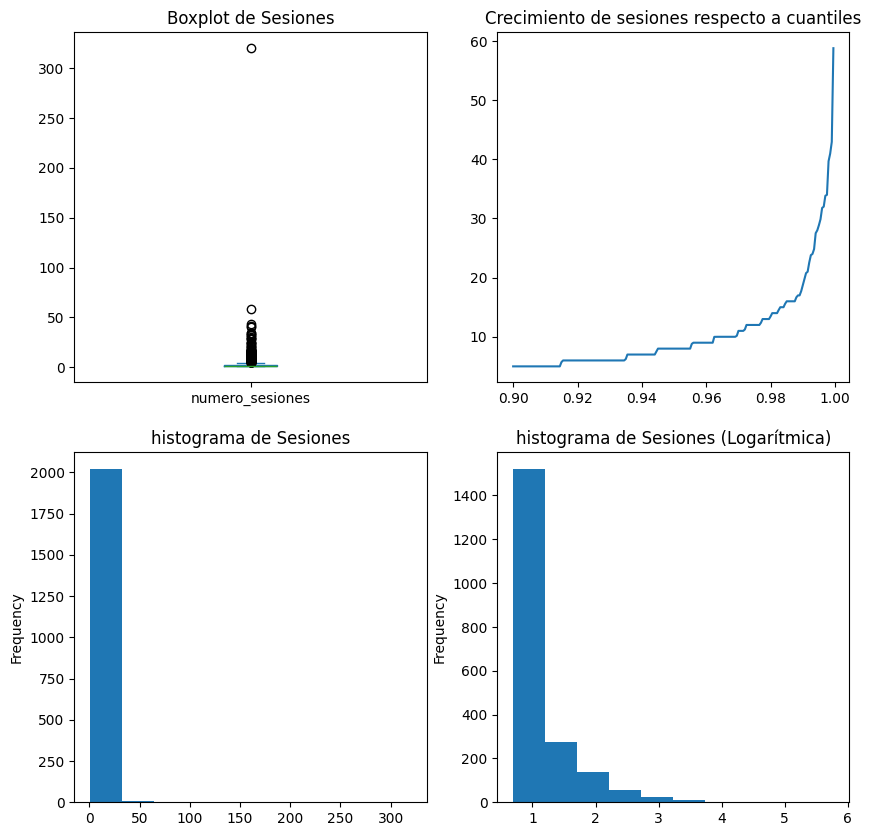

In [16]:
fig, axes = plt.subplots(2,2, figsize = (10, 10))

frame['sesiones_np1log'] = np.log1p(frame['numero_sesiones'])

frame['numero_sesiones'].plot(kind = 'box', ax = axes[0,0], title='Boxplot de Sesiones')
quantiles.plot(title='Crecimiento de sesiones respecto a cuantiles', ax = axes[0,1])
frame['numero_sesiones'].plot(kind = 'hist', ax = axes[1,0], title = 'histograma de Sesiones')
frame['sesiones_np1log'].plot(kind = 'hist', ax = axes[1,1], title = 'histograma de Sesiones (Logarítmica)')

plt.show()

## Conclusiòn sobre sesiones de mapa geoespacial

Existe un grupo minorista que esta haciendo uso intensivo de la aplicación, desde la perspectiva de producto, podriamos valorar que usuarios que incluso alcanzan hasta 15 busquedas por sesión podrían ser power users, no obstante 

In [17]:
frame_sospechoso = frame[frame['numero_sesiones'] > 20]
frame_sospechoso

,ga_client_id,numero_sesiones,sesiones_np1log
4,1002997908.1774214430,21,3.091042
23,1022937825.1775508029,29,3.401197
34,1035321272.1774409073,32,3.496508
59,1056701857.1775496428,24,3.218876
204,1196455460.1773716400,34,3.555348
300,1291894832.1776976580,32,3.496508
739,1711280902.1774364894,24,3.218876
839,1799528631.1771252888,40,3.713572
931,1896702802.1773694145,59,4.094345
1118,2056870125.1776564181,28,3.367296


In [18]:
row_random = np.random.randint(0, len(frame_sospechoso), 1)
finder_user = frame_sospechoso.iloc[row_random, :]['ga_client_id'].values[0]

In [19]:
finder_user

'609057346.1773768906'

In [20]:
busquedas_completas[busquedas_completas['ga_client_id'] == finder_user]

,search_id,created_at,search_source,nivel,tipo,route_path,cct_context,center_lat,center_lon,radius_m,status,result_count,error_code,duration_ms,app_session_id,ga_client_id,ga_session_id,premium_schools,aparicion_premium,postal_code_used
404,c478facc-8bd6-4bdb-95be-be0173f24a9d,2026-03-17T17:35:11.282917+00:00,near_me,secundaria,publicas,/secundaria,NaN,19.612032,-99.324840,1500,success,3,NaN,418,1943ea47-6170-44c1-8414-4be7d2699caf,609057346.1773768906,1773768905,[],False,NaN
405,6fd19c6a-a8c1-42ac-abe7-583aa9774e56,2026-03-17T17:37:21.468799+00:00,near_me,secundaria,publicas,/secundaria,NaN,19.612032,-99.324840,1500,success,3,NaN,396,5723833b-1b1a-449f-94b7-aded211c1810,609057346.1773768906,1773768905,[],False,NaN
406,b0b77d07-16d3-4098-95ea-d0c4d55461f2,2026-03-17T17:37:54.049931+00:00,map_drag,secundaria,publicas,/secundaria,NaN,19.604887,-99.329676,1500,success,1,NaN,393,5723833b-1b1a-449f-94b7-aded211c1810,609057346.1773768906,1773768905,[],False,NaN
407,6cbc6a4c-d08c-4426-b152-f1dc0f0a4ef1,2026-03-17T17:37:57.511581+00:00,map_drag,secundaria,publicas,/secundaria,NaN,19.598176,-99.329547,1500,success,1,NaN,244,5723833b-1b1a-449f-94b7-aded211c1810,609057346.1773768906,1773768905,[],False,NaN
408,1a1430f9-0d28-4d90-ad51-45b820a0098f,2026-03-17T17:38:05.050822+00:00,map_drag,secundaria,publicas,/secundaria,NaN,19.600521,-99.319720,1500,success,2,NaN,307,5723833b-1b1a-449f-94b7-aded211c1810,609057346.1773768906,1773768905,[],False,NaN
409,8b917726-7c1d-468d-bbca-bae4aff654ac,2026-03-17T17:38:12.698253+00:00,map_drag,secundaria,publicas,/secundaria,NaN,19.614024,-99.333925,1500,success,1,NaN,217,5723833b-1b1a-449f-94b7-aded211c1810,609057346.1773768906,1773768905,[],False,NaN
410,8cd7f57c-b3d3-4c56-a8e3-c83e916a2d91,2026-03-17T17:38:19.074274+00:00,map_drag,secundaria,publicas,/secundaria,NaN,19.609900,-99.341177,1500,success,2,NaN,258,5723833b-1b1a-449f-94b7-aded211c1810,609057346.1773768906,1773768905,[],False,NaN
411,ee8925cc-91f6-4785-83fc-3067fb83a4ae,2026-03-17T17:38:46.37977+00:00,map_drag,secundaria,publicas,/secundaria,NaN,19.606585,-99.352035,1500,success,2,NaN,340,5723833b-1b1a-449f-94b7-aded211c1810,609057346.1773768906,1773768905,[],False,NaN
412,f7aa20a1-b2cc-4e91-b628-5487a9985d0f,2026-03-17T17:38:48.314402+00:00,map_drag,secundaria,publicas,/secundaria,NaN,19.602543,-99.356627,1500,success,2,NaN,221,5723833b-1b1a-449f-94b7-aded211c1810,609057346.1773768906,1773768905,[],False,NaN
413,09265bb3-bfaf-46ba-aecc-4d9bfef5714d,2026-03-17T17:40:02.832107+00:00,map_drag,secundaria,publicas,/secundaria,NaN,19.592046,-99.373379,1500,success,0,NaN,392,5723833b-1b1a-449f-94b7-aded211c1810,609057346.1773768906,1773768905,[],False,NaN


## Insight

Es necesario agregar a la data de Google Analytics y TAG el id de la busqueda que se genera dento del sitio web. También debe ser modificado el esquema de datos de postgres para almacenar el user agent del dispositivo, de lo contrario no podremos conocer patrones vitales de uso. Con esa data podríamos incluso generar las primeras reglas de rate limiting para evitar abusos.

Recomendaciones:

- Añadir a la data de eventos de BigQuery el tag relacionado a id de busqueda de la webapp
- Almacenar en postgreSQL el user agent de la busqueda.

In [21]:
big[big['user_pseudo_id'] == finder_user]

,event_date,event_timestamp,event_name,user_pseudo_id,school_path,tipo,nivel,cta_placement,surface,page_location,cct,route_path,device,ga_session_id,ga_session_number,batch_page_id


## Insight

He logrado detectar que existe un grupo de usuarios que estan haciendo uso intensivo de la aplicación, también por ejmeplo el user con pseudo '1002997908.1774214430' al ser analizado en BigQUERY tuvo un conteo de 128 eventos de interacción con el producto.

Podriamos analizar en profundidad el comportamiento de este tipo de usuarios, y valorar cuales de ellos son sospechosos para poder crear un modelo que permita identificar a sospechosos y aplicarles rate limiting.

No obstante el objetivo de este proyecto no es llevar el análisis a tal complejidad. No obstante con el nivel de usuarios y con la capacidad de recolección de datos de navegación esto podria resultar como un gran producto de seguridad para prevenir mal uso de servicios.

## Parte 2

En este punto ya habia identificado anomalías de tráfico y userAgents no asociados a una tag de Google Analytics, por lo que es aquí donde consumo los Vercel Logs para poder empezar a comprender el comportamiento de estos usuarios del sitio y empujar el proyecto hacia clasificación no supervisada.

In [22]:
vercel_path = ROOT_PROJECT / 'Data' / 'vercel_logs'
vercel_logs = os.path.join(vercel_path, 'last_10k.csv')

data_logs = pd.read_csv(vercel_logs)
data_logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10057 entries, 0 to 10056
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TimeUTC             10057 non-null  object 
 1   timestampInMs       10057 non-null  int64  
 2   requestPath         10057 non-null  object 
 3   requestMethod       10057 non-null  object 
 4   requestQueryString  1390 non-null   object 
 5   responseStatusCode  10057 non-null  int64  
 6   requestId           10057 non-null  object 
 7   requestUserAgent    10057 non-null  object 
 8   level               5 non-null      object 
 9   environment         10057 non-null  object 
 10  branch              10045 non-null  object 
 11  vercelCache         10049 non-null  object 
 12  type                10057 non-null  object 
 13  function            10057 non-null  object 
 14  host                10057 non-null  object 
 15  deploymentDomain    10049 non-null  object 
 16  depl

In [23]:
data_logs['maxMemoryUsed'].describe()

count    1016.000000
mean      321.587598
std        13.637683
min       259.000000
25%       313.000000
50%       323.000000
75%       330.000000
max       350.000000
Name: maxMemoryUsed, dtype: float64

In [24]:
data_logs['memorySize'].describe()

count    1016.0
mean     1769.0
std         0.0
min      1769.0
25%      1769.0
50%      1769.0
75%      1769.0
max      1769.0
Name: memorySize, dtype: float64

In [25]:
agents_data = (
    data_logs
    .groupby('requestUserAgent')
    .agg(
        cantidadSesiones = ('requestUserAgent', 'count'),
        maxMemoryUsed= ('maxMemoryUsed', 'sum'),
        memorySize = ('memorySize', 'sum'),
        durationMs = ('durationMs', 'sum'),
    ).reset_index()
)

In [26]:
agents_data = agents_data.sort_values(by = 'maxMemoryUsed', ascending= False)
agents_data

,requestUserAgent,cantidadSesiones,maxMemoryUsed,memorySize,durationMs
1156,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",3933,216928.0,1194075.0,675194.0
1153,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",1544,59806.0,325496.0,225506.0
856,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,207,5133.0,28304.0,43638.0
312,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,551,4281.0,22997.0,122530.0
23,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,464,3909.0,22997.0,44486.0
...,...,...,...,...,...
414,Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build...,1,0.0,0.0,368.0
415,Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build...,1,0.0,0.0,24.0
416,Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build...,1,0.0,0.0,260.0
417,Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build...,1,0.0,0.0,78.0


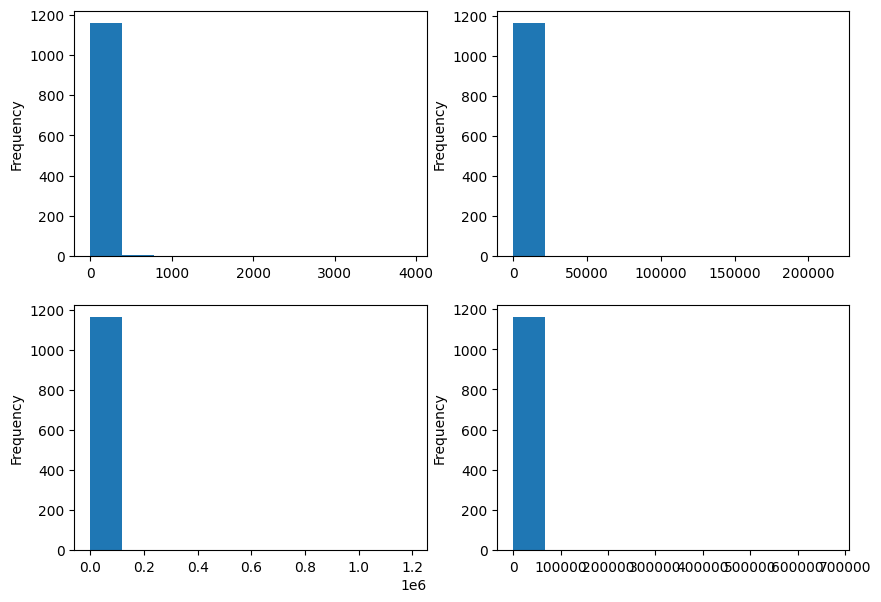

In [27]:
plot_ancho = 2
plot_alto = 2
fig, axes = plt.subplots(plot_ancho,plot_alto, figsize = (10, 7))

columnas_plot = agents_data.drop(columns = 'requestUserAgent').columns

for i, columna in enumerate(columnas_plot):
    
    row = i // plot_alto
    column = i % plot_alto
    agents_data[columna].plot(kind = 'hist', ax = axes[row, column])


In [28]:
agents_data['requestUserAgent'].unique()

array(['Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Gecko; compatible; bingbot/2.0; +http://www.bing.com/bingbot.htm) Chrome/116.0.1938.76 Safari/537.36',
       'Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Gecko; compatible; GPTBot/1.4; +https://openai.com/gptbot)',
       'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/133.0.6943.141 Safari/537.36',
       ...,
       'Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build/MRA58N) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/47.0.8270.1796 Mobile Safari/537.36',
       'Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build/MRA58N) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/47.0.8632.1960 Mobile Safari/537.36',
       'Mozilla/5.0 (Linux; Android 8.0; Pixel 2 Build/OPD3.170816.012) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.4975.1387 Mobile Safari/537.36'],
      shape=(1166,), dtype=object)

In [29]:
data_logs

,TimeUTC,timestampInMs,requestPath,requestMethod,requestQueryString,responseStatusCode,requestId,requestUserAgent,level,environment,...,memorySize,message,projectId,traceId,sessionId,invocationId,instanceId,concurrency,workflowRunId,workflowStepId
0,2026-05-23 14:00:49,1779544849497,www.edunautica.mx/primaria/chiapas/salto-de-ag...,GET,NaN,200,rxbrz-1779544849497-ba26cf5c5028,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",NaN,production,...,1769.0,NaN,prj_nwIRmq24lkswGJuLbRfvoOznTONg,NaN,NaN,01KSAJ6Z7GR8Q9BJ86D1GZEQ65,qz7CR4AEiFyU,1.0,NaN,NaN
1,2026-05-23 14:00:48,1779544848738,www.edunautica.mx/secundaria/queretaro/huimilp...,GET,NaN,200,bmvgl-1779544848738-33094f1dda7d,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,production,...,NaN,NaN,prj_nwIRmq24lkswGJuLbRfvoOznTONg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-05-23 14:00:47,1779544847785,www.edunautica.mx/primaria/guerrero/cuautepec,GET,NaN,200,t98l6-1779544847785-cf59630818ab,meta-externalagent/1.1 (+https://developers.fa...,NaN,production,...,NaN,NaN,prj_nwIRmq24lkswGJuLbRfvoOznTONg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-05-23 14:00:46,1779544846603,www.edunautica.mx/cct,GET,cct=30DTV1834F&nivel=secundaria,200,4rzq2-1779544846603-8352b88e0e5c,Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build...,NaN,production,...,NaN,NaN,prj_nwIRmq24lkswGJuLbRfvoOznTONg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-05-23 14:00:45,1779544845200,www.edunautica.mx/primaria/guanajuato/leon/urb...,GET,NaN,200,vgsgd-1779544845200-3bd156e8a07d,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,NaN,production,...,NaN,NaN,prj_nwIRmq24lkswGJuLbRfvoOznTONg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10052,2026-05-23 08:59:17,1779526757229,www.edunautica.mx/primaria/veracruz/alamo-tema...,GET,NaN,200,tsc28-1779526757229-75bc134bdd26,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",NaN,production,...,NaN,NaN,prj_nwIRmq24lkswGJuLbRfvoOznTONg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10053,2026-05-23 08:59:06,1779526746411,www.edunautica.mx/primaria/veracruz/chiconquia...,GET,NaN,200,69wjf-1779526746411-92f460bb5aad,Mozilla/5.0 (iPhone; CPU iPhone OS 7_0 like Ma...,NaN,production,...,NaN,NaN,prj_nwIRmq24lkswGJuLbRfvoOznTONg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10054,2026-05-23 08:59:06,1779526746270,www.edunautica.mx/primaria/veracruz/alamo-tema...,GET,NaN,200,xpmb4-1779526746270-3be35ae513f6,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",NaN,production,...,NaN,NaN,prj_nwIRmq24lkswGJuLbRfvoOznTONg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10055,2026-05-23 08:58:55,1779526735551,www.edunautica.mx/primaria/michoacan/alvaro-ob...,GET,NaN,200,tkzmm-1779526735551-0f9aa19b833c,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",NaN,production,...,NaN,NaN,prj_nwIRmq24lkswGJuLbRfvoOznTONg,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Fin del EDA Fase 1

Hemos detectado insights valiosos para negocio que son estadisticamente confiables, y además pudimos detectar que existe una cantidad relevante de usuarios que parecen tener flujos automatizados, esto nos prepara para la siguiente fase, donde entrenaremos un modelo no supervisado para detectar agentes posiblemente fraudulentos para generar observabilidad sobre ellos, no buscaremos crear un modelo de ciberseguridad pero si un modelo para clasificar el comportamiento anomalo de dichos agentes crawlers.

---